In [1]:
#Name: SHreetu Shrestha
#Student ID:2417729
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image, UnidentifiedImageError
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
train_dir = "/Users/shreetu/Documents/more of AI/W7/DevanagariHandwrittenDigitDataset/train"

test_dir = "/Users/shreetu/Documents/more of AI/W7/DevanagariHandwrittenDigitDataset/test"

train_class_names = sorted(os.listdir(train_dir))

if not train_class_names:
    print("No class directories found in training folder")
else:
    print(f"Found {len(train_class_names)} classes in train: {(train_class_names)}")

test_class_names = sorted(os.listdir(test_dir))

if not test_class_names:
    print("No class directories found in testing folder")
else:
    print(f"Found {len(test_class_names)} classes in test: {(test_class_names)}")

Found 11 classes in train: ['.DS_Store', 'digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Found 11 classes in test: ['.DS_Store', 'digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [3]:
train_corrupted_images = []

for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)  # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except ( IOError, UnidentifiedImageError):
                train_corrupted_images.append(img_path)

# Print results
if train_corrupted_images:
    print("\n Total corrupted images found is traning dataset:", len(train_corrupted_images))
    print("\nCorrupted Images Found in traning dataset:")
    for img in train_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in traning dataset.")


No corrupted images found in traning dataset.


In [4]:
test_corrupted_images = []

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)  # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except ( IOError, UnidentifiedImageError):
                test_corrupted_images.append(img_path)

# Print results
if test_corrupted_images:
    print("\n Total corrupted images found is testing dataset:", len(test_corrupted_images))
    print("\nCorrupted Images Found in testing dataset:")
    for img in test_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in testing dataset.")


No corrupted images found in testing dataset.


In [6]:
total_train_image_count = 0

for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # os.listdir gets EVERY file in the folder
        images_in_folder = os.listdir(class_path) 
        total_train_image_count += len(images_in_folder)

print(f"Total images in folder (Valid + Corrupted): {total_train_image_count}")
print(f"Total Valid images:     {total_train_image_count - len(train_corrupted_images)}")
print(f"Total Corrupted images: {len(train_corrupted_images)}")

Total images in folder (Valid + Corrupted): 17000
Total Valid images:     17000
Total Corrupted images: 0


In [8]:
total_test_image_count = 0

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        # os.listdir gets EVERY file in the folder
        images_in_folder = os.listdir(class_path) 
        total_test_image_count += len(images_in_folder)

print(f"Total images in folder (Valid + Corrupted): {total_test_image_count}")
print(f"Total Valid images:     {total_test_image_count - len(test_corrupted_images)}")
print(f"Total Corrupted images: {len(test_corrupted_images)}")

Total images in folder (Valid + Corrupted): 3000
Total Valid images:     3000
Total Corrupted images: 0


In [10]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42
NOISE_STDDEV = 0.1

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',      
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation',
    shuffle=True
)


def normalize_and_reshape(images, labels):
    # Cast to float32 and normalize to [0, 1]
    images = tf.cast(images, tf.float32) / 255.0
    # Explicitly ensure shape: (batch, 32, 32, 1)
    images = tf.reshape(images, [-1, IMG_SIZE[0], IMG_SIZE[1], 1])
    return images, labels

train_ds = train_ds.map(normalize_and_reshape, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(normalize_and_reshape, num_parallel_calls=tf.data.AUTOTUNE)

def add_gaussian_noise(images, labels, stddev=NOISE_STDDEV):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=stddev)
    noisy = tf.clip_by_value(images + noise, 0.0, 1.0)
    return noisy, images  # x = noisy, y = clean (target)

train_ds = train_ds.map(lambda x, y: add_gaussian_noise(x, y, stddev=NOISE_STDDEV))
val_ds   = val_ds.map(lambda x, y: add_gaussian_noise(x, y, stddev=NOISE_STDDEV))

Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Found 17000 files belonging to 10 classes.
Using 3400 files for validation.


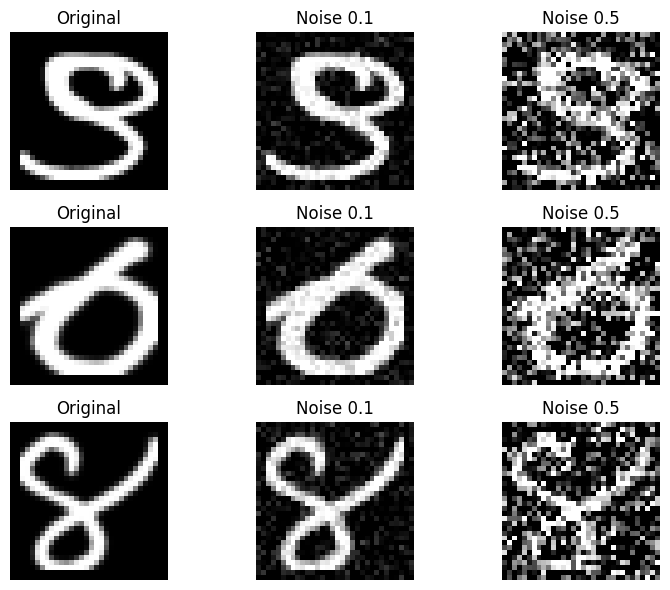

In [11]:
batch = next(iter(train_ds))
noisy_images, clean_images = batch

sample_indices = [0, 1, 2]

plt.figure(figsize=(8, 6))

for i, idx in enumerate(sample_indices):

    original_img = np.squeeze(clean_images[idx].numpy())
    
    noise_01 = np.random.normal(loc=0.0, scale=0.1, size=original_img.shape)
    img_01 = np.clip(original_img + noise_01, 0.0, 1.0)
    
    noise_05 = np.random.normal(loc=0.0, scale=0.5, size=original_img.shape)
    img_05 = np.clip(original_img + noise_05, 0.0, 1.0)
    
    images = [original_img, img_01, img_05]
    titles = ["Original", "Noise 0.1", "Noise 0.5"]
    
    for j in range(3):
        plt.subplot(3, 3, i * 3 + j + 1)
        plt.imshow(images[j], cmap='gray')
        plt.title(titles[j])
        plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [15]:
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [16]:
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [19]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_autoencoder.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


EPOCHS = 20
BATCH_SIZE = 32

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2335
Epoch 1: val_loss improved from None to 0.12205, saving model to best_autoencoder.h5



Epoch 1: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1577 - val_loss: 0.1220
Epoch 2/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1208
Epoch 2: val_loss improved from 0.12205 to 0.11723, saving model to best_autoencoder.h5



Epoch 2: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1198 - val_loss: 0.1172
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1170
Epoch 3: val_loss improved from 0.11723 to 0.11543, saving model to best_autoencoder.h5



Epoch 3: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1167 - val_loss: 0.1154
Epoch 4/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1153
Epoch 4: val_loss improved from 0.11543 to 0.11413, saving model to best_autoencoder.h5



Epoch 4: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1151 - val_loss: 0.1141
Epoch 5/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1141
Epoch 5: val_loss improved from 0.11413 to 0.11352, saving model to best_autoencoder.h5


...


Epoch 16: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1100 - val_loss: 0.1096
Epoch 17/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1098
Epoch 17: val_loss improved from 0.10965 to 0.10947, saving model to best_autoencoder.h5



Epoch 17: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1099 - val_loss: 0.1095
Epoch 18/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1096
Epoch 18: val_loss improved from 0.10947 to 0.10939, saving model to best_autoencoder.h5



Epoch 18: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1097 - val_loss: 0.1094
Epoch 19/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1095
Epoch 19: val_loss improved from 0.10939 to 0.10919, saving model to best_autoencoder.h5



Epoch 19: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1097 - val_loss: 0.1092
Epoch 20/20
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1094
Epoch 20: val_loss improved from 0.10919 to 0.10911, saving model to best_autoencoder.h5



Epoch 20: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1095 - val_loss: 0.1091
Restoring model weights from the end of the best epoch: 20.


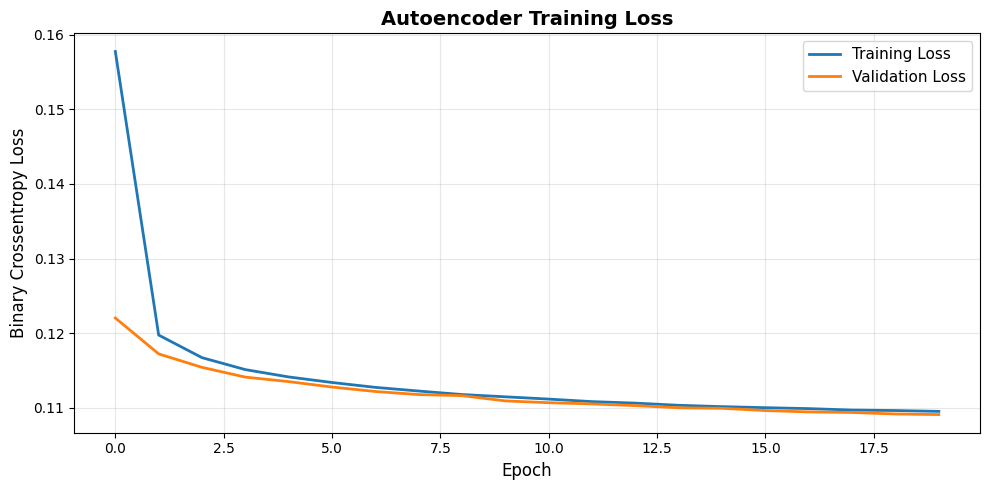

In [22]:
plt.figure(figsize=(10, 5))

# Training and Validation Loss
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Autoencoder Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

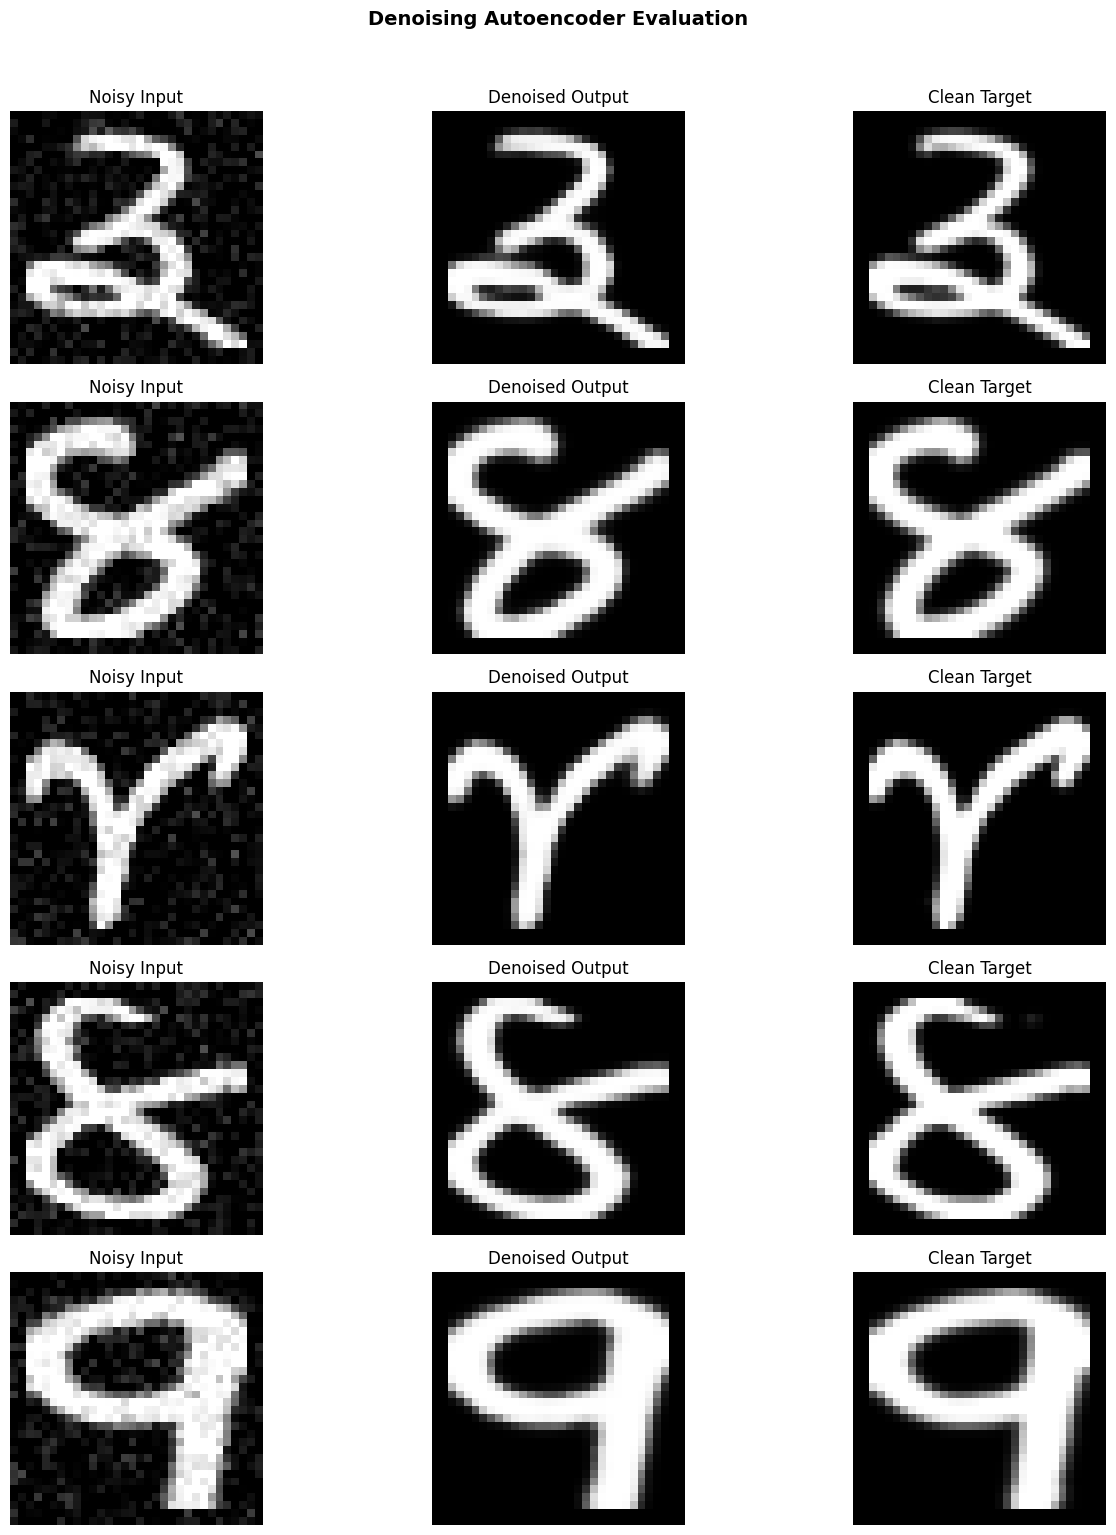

In [23]:
# Fetch a single batch from the validation set (unseen during training)
noisy_batch, clean_batch = next(iter(val_ds))

# Pass noisy images through the trained autoencoder
denoised_batch = autoencoder.predict(noisy_batch, verbose=0)

# Select random samples to display
n_samples = 5
sample_indices = np.random.choice(noisy_batch.shape[0], n_samples, replace=False)

plt.figure(figsize=(14, 3 * n_samples))

for i, idx in enumerate(sample_indices):
    # Remove channel dimension & convert to numpy
    noisy_img = np.squeeze(noisy_batch[idx].numpy())
    clean_img = np.squeeze(clean_batch[idx].numpy())
    denoised_img = np.squeeze(denoised_batch[idx])
    
    images = [noisy_img, denoised_img, clean_img]
    titles = ["Noisy Input", "Denoised Output", "Clean Target"]
    
    for j in range(3):
        plt.subplot(n_samples, 3, i * 3 + j + 1)
        plt.imshow(images[j], cmap='gray')
        plt.title(titles[j])
        plt.axis('off')

plt.suptitle("Denoising Autoencoder Evaluation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()